# Credit Risk — Predicting Loan Default

A worked classification study on the Kaggle
[credit risk dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)
(`laotse/credit-risk-dataset`): 32,581 granted loans described by twelve columns of
applicant, credit-bureau and underwriting information.

The dataset ships without a designated label — it is a bank's operational record — so the
first job is to argue for a target rather than look one up.

## Contents

| § | Section |
| --- | --- |
| 1 | [Setup](#1.-Setup) |
| 2 | [Choosing the dependent variable](#2.-Choosing-the-dependent-variable) |
| 3 | [How the variables relate](#3.-How-the-variables-relate) |
| 4 | [Three classifiers, cross-validated](#4.-Three-classifiers,-cross-validated) |
| 5 | [Hyperparameter optimisation](#5.-Hyperparameter-optimisation) |
| 6 | [Gradient boosting](#6.-Gradient-boosting) |
| 7 | [Robustness and what tuning does not buy](#7.-Robustness-and-what-tuning-does-not-buy) |
| 8 | [Summary](#8.-Summary) |

The pipeline itself lives in `src/`, so this notebook and `run_analysis.py` share one
implementation instead of drifting apart. `src/experiments.py` holds the search spaces;
`src/robustness.py` holds the diagnostics in §7.

---
## 1. Setup

### 1.1 Imports and configuration

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd() / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
%matplotlib inline

FIGURES = Path("reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

### 1.2 Load and clean

In [2]:
import eda
import robustness as rb
from data import TARGET, UNDERWRITING_FEATURES, load_credit_risk
from experiments import (
    RANDOM_STATE, cross_validate_baselines, gradient_boosting_spec,
    search_specs, search_trace, tune_all,
)
from preprocess import clean, feature_columns

dataset = load_credit_risk()
frame, clean_report = clean(dataset.frame)

print(f"source         : {dataset.source}")
print(f"rows x columns : {frame.shape[0]:,} x {frame.shape[1]}")
print(f"default rate   : {frame[TARGET].mean():.3%}")
print(f"cleaning       : {clean_report}")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  kagglehub download unavailable (ProxyError: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDataset (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))); using the stand-in
source         : synthetic
rows x columns : 32,574 x 12
default rate   : 22.116%
cleaning       : {'rows_before': 32581, 'impossible_age': 5, 'impossible_emp_length': 2, 'rows_after': 32574}


Cleaning removes only records that are *impossible* — ages above 100, employment histories
longer than a working life. Extreme-but-possible values (a $6M income, a loan worth 83% of
income) are kept: those are real applicants and the model has to cope with them.

> **Which data is this?** `load_credit_risk()` resolves in three steps: the real CSV in
> `data/`, then a `kagglehub` download, then a calibrated stand-in. If the line above reads
> `synthetic`, Kaggle was unreachable and **these numbers come from the stand-in, not the
> real file** — it reproduces the real marginals and conditional default rates but not the
> sharper joint structure, so absolute scores here run lower than the real data supports.
> Drop the real `data/credit_risk_dataset.csv` in and re-run to regenerate everything.

---
## 2. Choosing the dependent variable

Nothing in the file is marked as a label. A usable target has to be:

1. an **outcome**, not an input to the process that produced the row;
2. **unknown at decision time** — otherwise there is nothing to predict;
3. **low-cardinality** enough to serve as a classification label.

Only one column clears all three.

### 2.1 Column profile

In [3]:
display(eda.profile(frame))

,column,dtype,n_unique,missing,missing_pct,example
0,person_age,int64,44,0,0.00,23
1,person_income,int64,2463,0,0.00,97400
2,person_home_ownership,str,4,0,0.00,RENT
3,person_emp_length,float64,183,895,2.75,2.4
4,loan_intent,str,6,0,0.00,EDUCATION
5,loan_grade,str,7,0,0.00,A
6,loan_amnt,int64,345,0,0.00,6400
7,loan_int_rate,float64,1446,3114,9.56,7.45
8,loan_status,int64,2,0,0.00,0
9,loan_percent_income,float64,83,0,0.00,0.07


### 2.2 Candidate targets

Grouping the columns by what they actually are makes the choice obvious: applicant
attributes, application terms and bureau attributes are all *inputs*, and the lender's grade
and interest rate are its own pricing decision. One column is left.

In [4]:
display(eda.target_candidates(frame))

,column,n_unique,binary,kind
0,person_home_ownership,4,False,applicant attribute
1,person_age,44,False,applicant attribute
2,person_emp_length,183,False,applicant attribute
3,person_income,2463,False,applicant attribute
4,cb_person_default_on_file,2,True,credit bureau attribute
5,cb_person_cred_hist_length,28,False,credit bureau attribute
6,loan_grade,7,False,lender decision
7,loan_int_rate,1446,False,lender decision
8,loan_intent,6,False,loan application term
9,loan_percent_income,83,False,loan application term


### 2.3 Class balance

loan_status
0    25370
1     7204

base rate = 22.116%
a 'nobody defaults' classifier already scores 77.88% accuracy


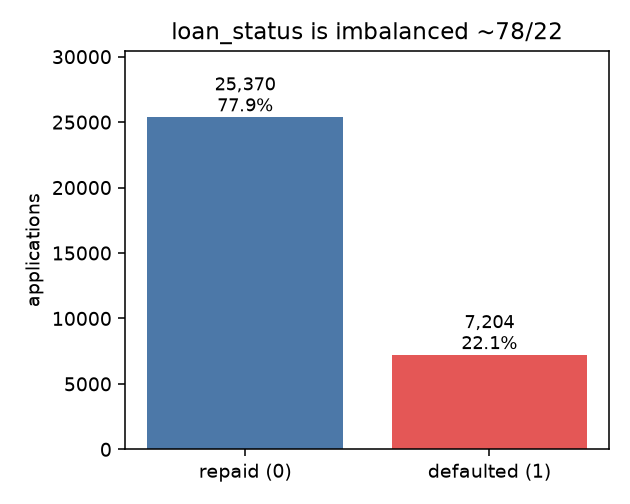

In [5]:
counts = frame[TARGET].value_counts().sort_index()
print(counts.to_string())
print(f"\nbase rate = {frame[TARGET].mean():.3%}")
print(f"a 'nobody defaults' classifier already scores {1 - frame[TARGET].mean():.2%} accuracy")

path = FIGURES / "01_target_balance.png"
if path.exists():
    display(Image(str(path)))

### 2.4 Conclusion

**The dependent variable is `loan_status`** — 1 = defaulted, 0 = repaid.

Two consequences shape everything downstream:

- **Classes are imbalanced ~78/22**, so accuracy is not a usable score. ROC-AUC is the
  selection metric here, with average precision, F1, balanced accuracy and the Brier score
  reported alongside because they answer different questions.
- **This file holds only loans that were already granted.** There are no declined applicants
  in it, so it supports modelling *default risk on approved loans* — an input to a granting
  decision, not the decision itself. That gap is survivorship bias, and §7.7 returns to it.

---
## 3. How the variables relate

Three questions: how strongly each feature relates to the target, which features duplicate
each other, and — the one that matters most here — which features are *consequences* of the
thing being predicted rather than independent measurements of the applicant.

### 3.1 Strength of association with the target

Point-biserial correlation for numeric columns, Cramér's V for categoricals, and mutual
information on the encoded matrix so the two families are directly comparable.

In [6]:
assoc = eda.association_with_target(frame)
display(assoc)

,feature,type,statistic,value,mutual_info
0,loan_grade,categorical,Cramer's V,0.416,0.0773
1,loan_percent_income,numeric,point-biserial r,0.388,0.0696
2,loan_int_rate,numeric,point-biserial r,0.335,0.0592
3,person_income,numeric,point-biserial r,-0.276,0.0636
4,person_home_ownership,categorical,Cramer's V,0.193,0.0409
5,cb_person_default_on_file,categorical,Cramer's V,0.134,0.0078
6,person_age,numeric,point-biserial r,-0.079,0.0024
7,loan_amnt,numeric,point-biserial r,0.074,0.0000
8,cb_person_cred_hist_length,numeric,point-biserial r,-0.069,0.0050
9,person_emp_length,numeric,point-biserial r,-0.051,0.0068


### 3.2 Default rate by category

In [7]:
for col, table in eda.default_rate_by_category(frame).items():
    print(f"\n{col}")
    print(table.to_string(index=False))


person_home_ownership
person_home_ownership     n  default_rate  share
             MORTGAGE 12333         0.139  0.379
                OTHER    94         0.181  0.003
                  OWN  1997         0.085  0.061
                 RENT 18150         0.292  0.557

loan_intent
      loan_intent    n  default_rate  share
DEBTCONSOLIDATION 5098         0.243  0.157
        EDUCATION 6385         0.219  0.196
  HOMEIMPROVEMENT 3688         0.217  0.113
          MEDICAL 6137         0.233  0.188
         PERSONAL 5518         0.215  0.169
          VENTURE 5748         0.199  0.176

cb_person_default_on_file
cb_person_default_on_file     n  default_rate  share
                        N 27220         0.196  0.836
                        Y  5354         0.347  0.164

loan_grade
loan_grade     n  default_rate  share
         A 10778         0.100  0.331
         B 10425         0.159  0.320
         C  6484         0.225  0.199
         D  3648         0.597  0.112
         E   978       

### 3.3 Correlation and redundancy

In [8]:
display(eda.numeric_correlations(frame))
display(eda.redundancy_check(frame))

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000,0.080,0.138,0.016,-0.111,-0.054,0.746,-0.086
person_income,0.080,1.000,0.010,0.258,-0.505,-0.553,0.066,-0.346
person_emp_length,0.138,0.010,1.000,-0.001,-0.100,-0.011,0.099,-0.047
loan_amnt,0.016,0.258,-0.001,1.000,0.017,0.621,0.010,0.076
loan_int_rate,-0.111,-0.505,-0.100,0.017,1.000,0.412,-0.089,0.320
loan_percent_income,-0.054,-0.553,-0.011,0.621,0.412,1.000,-0.047,0.336
cb_person_cred_hist_length,0.746,0.066,0.099,0.010,-0.089,-0.047,1.000,-0.071
loan_status,-0.086,-0.346,-0.047,0.076,0.320,0.336,-0.071,1.000


,feature_a,feature_b,spearman_rho,why
0,loan_percent_income,loan_amnt,0.621,numerator of the ratio
1,loan_percent_income,person_income,-0.553,denominator of the ratio
2,loan_int_rate,loan_grade,0.948,interest rate is priced off the grade
3,person_age,cb_person_cred_hist_length,0.746,history cannot start before adulthood


### 3.4 Distributions

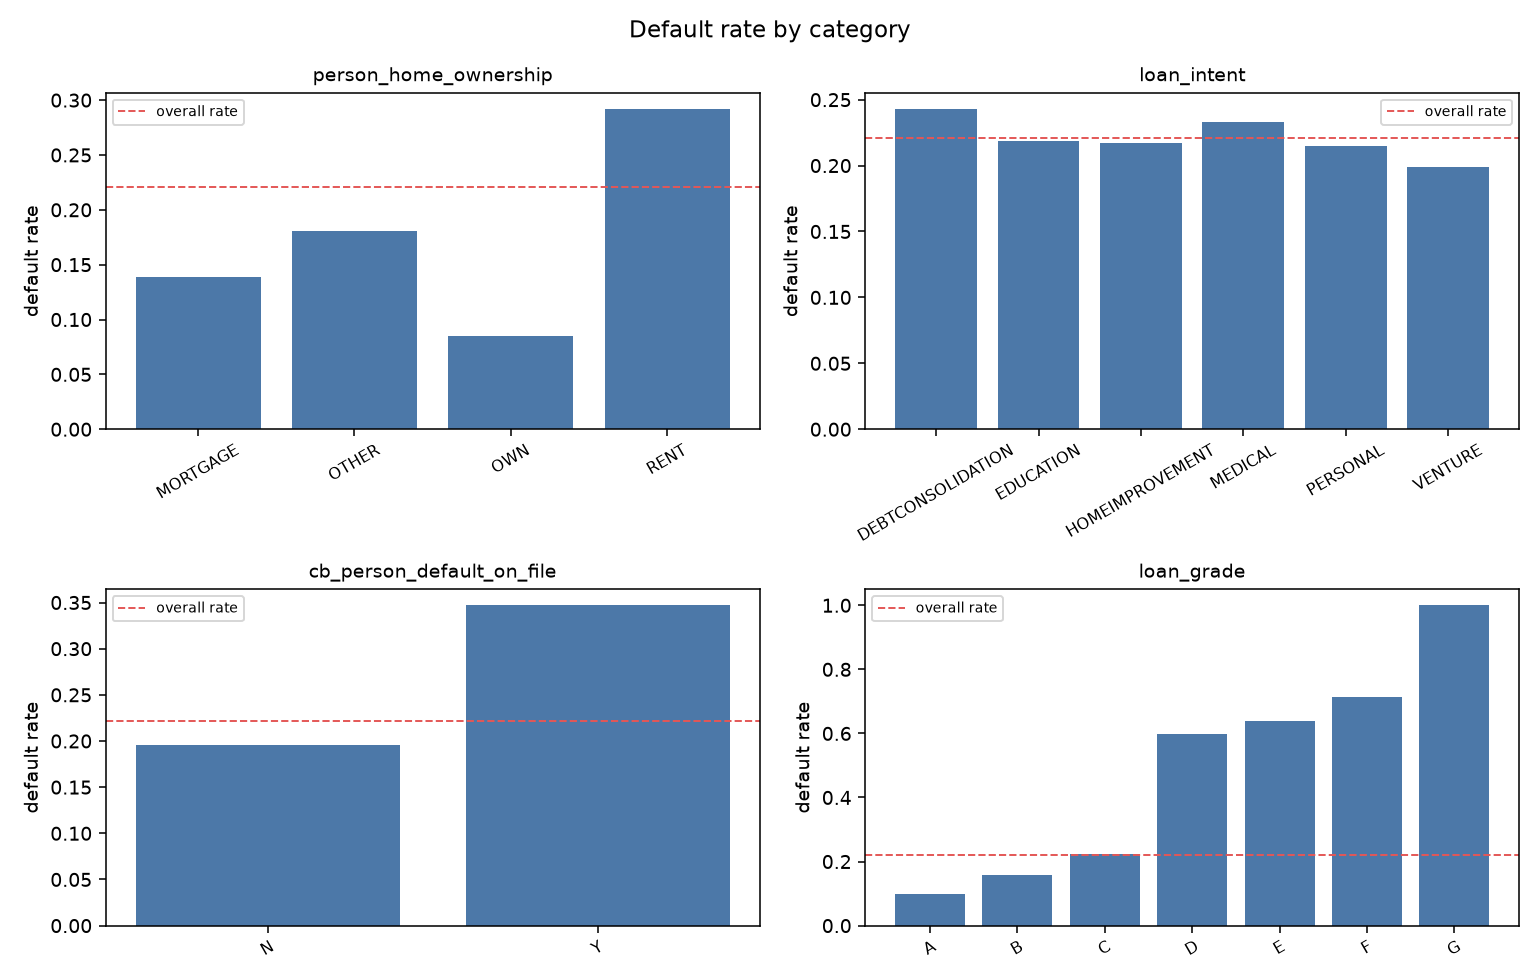

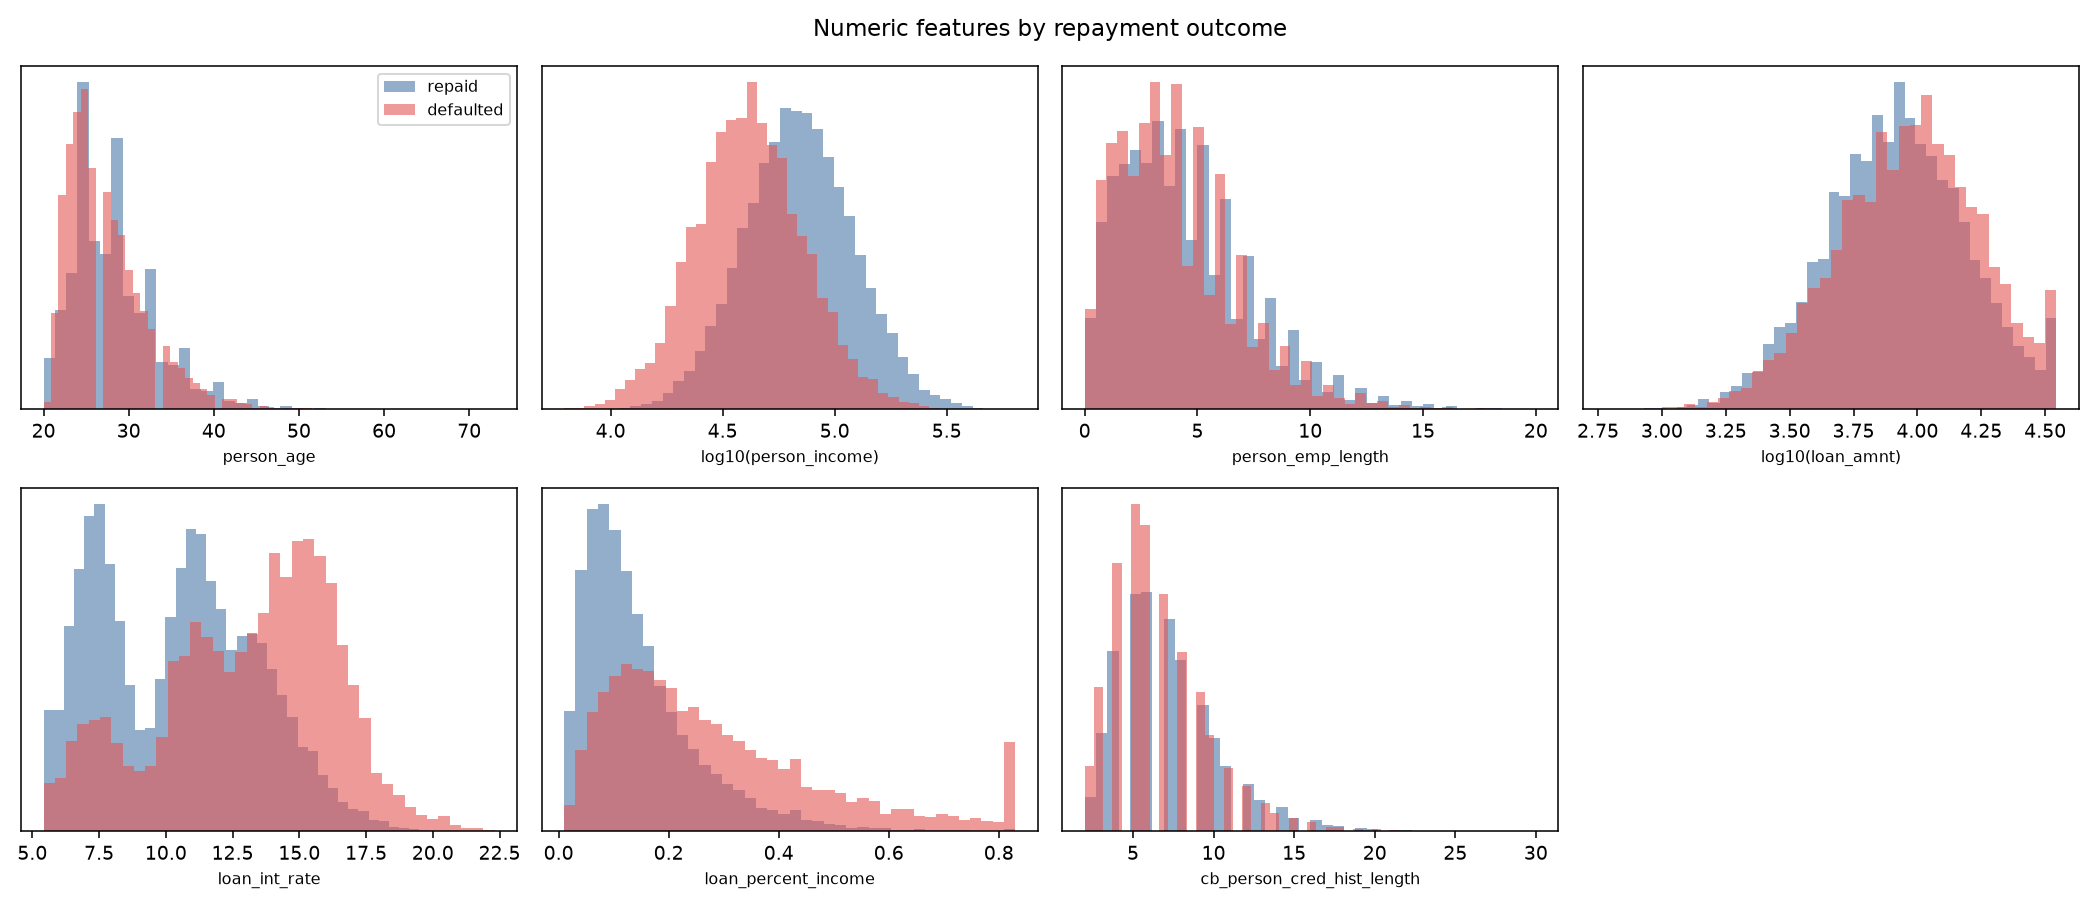

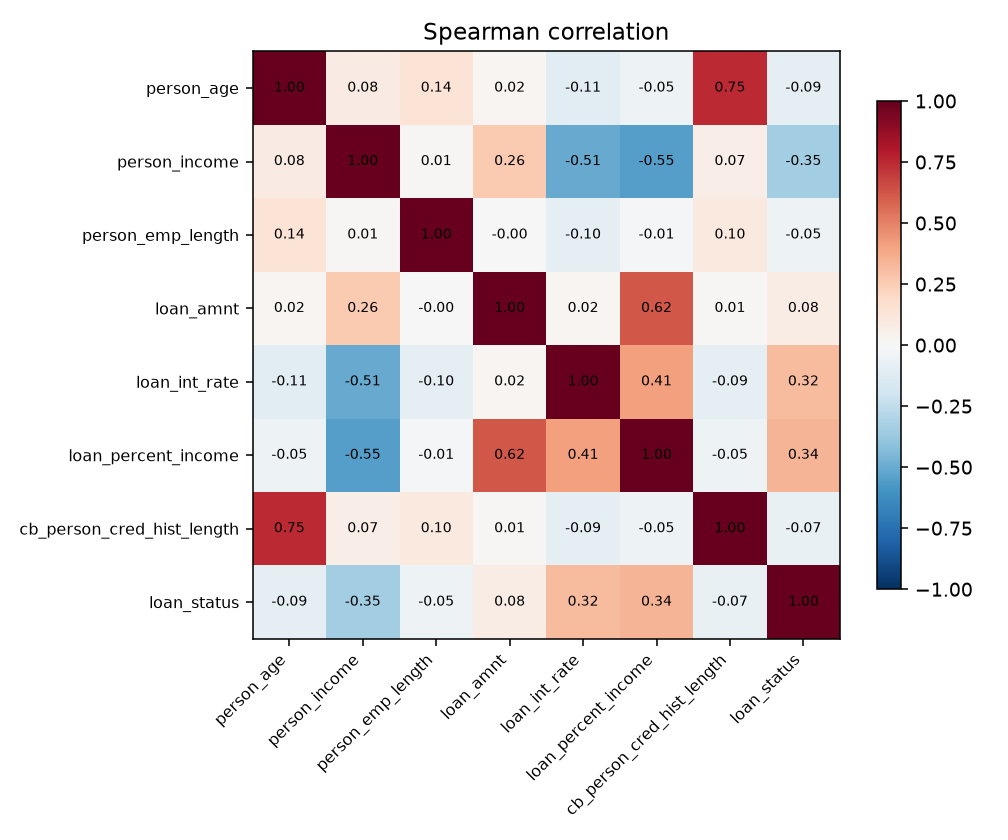

In [9]:
eda.write_figures(frame, FIGURES)
for name in ["02_default_rate_by_category.png",
             "03_numeric_by_outcome.png",
             "04_spearman_correlation.png"]:
    display(Image(str(FIGURES / name)))

### 3.5 What the structure means

**1. `loan_grade` and `loan_int_rate` are the lender's verdict, not the applicant's profile.**
They are the two strongest predictors precisely *because* an underwriter already compressed
the applicant's risk into them. That makes them **post-treatment variables**: legitimate if
the model runs *after* grading, leakage-like if it is meant to *replace* grading. §4.4 scores
both feature sets so the difference is measured rather than assumed.

**2. `loan_int_rate` is close to a lookup on `loan_grade`.** Harmless for tree ensembles; in
a linear model it splits one effect across two coefficients so neither looks important on its
own.

**3. `loan_percent_income` is `loan_amnt / person_income` by construction** — and it is the
strongest *applicant-side* signal. That is the substantive finding: what predicts default is
neither income nor loan size alone, but the ratio between them. Debt service capacity.

**4. `person_age` and `cb_person_cred_hist_length` are near-duplicates** — a credit file
cannot predate adulthood, so one of the two is largely redundant.

**5. Missingness is not random.** `loan_int_rate` and `person_emp_length` both have gaps.
Imputation is fitted *inside* each CV fold, never on the full dataset, so imputed values
never carry information from the validation split.

**6. Renters default far more than owners, and a prior default on file roughly doubles the
rate.** Collateral and past behaviour dominate — what the credit literature would predict.

---
## 4. Three classifiers, cross-validated

### 4.1 Protocol

- A stratified **20% test set is split off first** and touched exactly once, in §6.4.
- **5-fold stratified cross-validation** on the remaining 80%; stratification holds the ~22%
  default rate in every fold.
- Imputation, scaling and encoding live **inside** the pipeline and are re-fitted per fold.
  Fitting them on the full dataset first would leak validation statistics into training.
- Three learners spanning three inductive biases: linear (**logistic regression**), local
  non-parametric (**k-nearest neighbours**), non-linear ensemble (**random forest**).

### 4.2 Train/test split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    frame.drop(columns=[TARGET]), frame[TARGET],
    test_size=0.20, stratify=frame[TARGET], random_state=RANDOM_STATE,
)
full_cols = feature_columns(include_underwriting=True)
app_cols = feature_columns(include_underwriting=False)

print(f"train {len(X_train):,} ({y_train.mean():.2%} default)")
print(f"test  {len(X_test):,} ({y_test.mean():.2%} default)")
print(f"\nall features     ({len(full_cols)}): {full_cols}")
print(f"application-only ({len(app_cols)}): {app_cols}")
print(f"withheld as post-treatment: {UNDERWRITING_FEATURES}")

train 26,059 (22.12% default)
test  6,515 (22.12% default)

all features     (11): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership', 'loan_intent', 'cb_person_default_on_file', 'loan_grade']
application-only (9): ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
withheld as post-treatment: ['loan_grade', 'loan_int_rate']


### 4.3 Baseline results, default settings

In [11]:
baseline = cross_validate_baselines(X_train, y_train, full_cols)
display(baseline)

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,brier_mean,brier_std,train_roc_auc_mean,overfit_gap,fit_seconds
0,LogisticRegression,0.8079,0.0066,0.5990,0.0093,0.4736,0.0147,0.6572,0.0072,0.8249,0.0023,0.1288,0.0016,0.8088,0.0009,2.8
2,RandomForest,0.8000,0.0071,0.5919,0.0090,0.4990,0.0079,0.6708,0.0045,0.8251,0.0016,0.1301,0.0015,1.0000,0.2000,23.3
1,KNeighbors,0.7339,0.0078,0.4603,0.0096,0.4581,0.0111,0.6504,0.0059,0.8027,0.0036,0.1521,0.0026,0.8954,0.1615,11.6


### 4.4 Withholding the lender's grade and rate

Predicting from what the applicant actually reports, with the underwriter's verdict removed:

In [12]:
baseline_app = cross_validate_baselines(X_train, y_train, app_cols)
display(baseline_app)

delta = (baseline.set_index("model")["roc_auc_mean"]
         - baseline_app.set_index("model")["roc_auc_mean"])
print("ROC-AUC lost when loan_grade and loan_int_rate are withheld:")
print(delta.round(4).to_string())

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,accuracy_mean,accuracy_std,brier_mean,brier_std,train_roc_auc_mean,overfit_gap,fit_seconds
0,LogisticRegression,0.8035,0.0060,0.5854,0.0117,0.4495,0.0130,0.6455,0.0062,0.8204,0.0019,0.1309,0.0018,0.8045,0.0010,0.6
2,RandomForest,0.7853,0.0052,0.5566,0.0090,0.4545,0.0136,0.6481,0.0069,0.8126,0.0034,0.1360,0.0014,1.0000,0.2147,19.7
1,KNeighbors,0.7136,0.0032,0.4289,0.0079,0.4216,0.0155,0.6313,0.0079,0.7942,0.0041,0.1582,0.0016,0.8880,0.1744,11.0


ROC-AUC lost when loan_grade and loan_int_rate are withheld:
model
LogisticRegression    0.0044
RandomForest          0.0147
KNeighbors            0.0203


The drop is the share of apparent performance that comes from the underwriter's verdict
rather than from anything the applicant reported. It is smaller than one might expect, which
says the grade is largely *derived from* the same applicant attributes the model already
sees — a summary of the inputs, not new information on top of them.

---
## 5. Hyperparameter optimisation

Three hyperparameters per classifier, each spanning a real range rather than a neighbourhood
of the default. Same folds and same seed as §4, so the comparison is like-for-like.

### 5.1 Search spaces

In [13]:
specs = search_specs()
for s in specs:
    print(f"{s.name}  ({s.strategy} search{'; ' + s.notes if s.notes else ''})")
    for k, why in s.tuned.items():
        print(f"    {k:20s} {str(s.param_grid['clf__' + k]):38s} {why}")
    print()

LogisticRegression  (grid search)
    C                    [0.01, 0.1, 0.5, 1.0, 5.0, 20.0]       inverse regularisation strength
    l1_ratio             [0.0, 1.0]                             pure L2 shrinkage (0.0) vs pure L1 sparsity (1.0)
    class_weight         [None, 'balanced']                     whether to re-weight the 22% minority class

KNeighbors  (grid search)
    n_neighbors          [5, 15, 31, 63, 101]                   neighbourhood size (bias/variance dial)
    weights              ['uniform', 'distance']                uniform vs inverse-distance voting
    p                    [1, 2]                                 Manhattan vs Euclidean metric

RandomForest  (random search; randomised over a 48-point grid to keep the run affordable)
    max_depth            [6, 10, 16, None]                      how far each tree may grow
    min_samples_leaf     [1, 5, 20, 50]                         smoothing / minimum leaf support
    max_features         ['sqrt', 0.5, None] 

### 5.2 Results

In [14]:
tuned, searches = tune_all(specs, X_train, y_train, full_cols)
display(tuned[["model", "n_candidates", "best_params", "roc_auc_mean", "roc_auc_std",
               "pr_auc_mean", "train_roc_auc_mean", "overfit_gap", "search_seconds"]])

,model,n_candidates,best_params,roc_auc_mean,roc_auc_std,pr_auc_mean,train_roc_auc_mean,overfit_gap,search_seconds
2,RandomForest,20,"{'min_samples_leaf': 50, 'max_features': 'sqrt...",0.8120,0.0067,0.6090,0.8358,0.0238,275.5
0,LogisticRegression,24,"{'C': 0.1, 'class_weight': 'balanced', 'l1_rat...",0.8081,0.0068,0.5983,0.8090,0.0009,24.3
1,KNeighbors,20,"{'n_neighbors': 101, 'p': 1, 'weights': 'dista...",0.8006,0.0074,0.5934,1.0000,0.1994,349.4


### 5.3 Search traces

In [15]:
for name, search in searches.items():
    print(f"\n=== {name} — top candidates ===")
    display(search_trace(search))


=== LogisticRegression — top candidates ===


,params,roc_auc_mean,roc_auc_std
0,"{'C': 0.1, 'class_weight': 'balanced', 'l1_rat...",0.8081,0.0068
1,"{'C': 0.1, 'class_weight': 'balanced', 'l1_rat...",0.8081,0.0067
2,"{'C': 0.5, 'class_weight': 'balanced', 'l1_rat...",0.8080,0.0067
3,"{'C': 0.5, 'class_weight': 'balanced', 'l1_rat...",0.8080,0.0067
4,"{'C': 0.5, 'class_weight': None, 'l1_ratio': 1.0}",0.8080,0.0067



=== KNeighbors — top candidates ===


,params,roc_auc_mean,roc_auc_std
0,"{'n_neighbors': 101, 'p': 1, 'weights': 'dista...",0.8006,0.0074
1,"{'n_neighbors': 101, 'p': 1, 'weights': 'unifo...",0.8003,0.0072
2,"{'n_neighbors': 101, 'p': 2, 'weights': 'dista...",0.7988,0.0079
3,"{'n_neighbors': 101, 'p': 2, 'weights': 'unifo...",0.7985,0.0079
4,"{'n_neighbors': 63, 'p': 1, 'weights': 'distan...",0.7967,0.0090



=== RandomForest — top candidates ===


,params,roc_auc_mean,roc_auc_std
0,"{'min_samples_leaf': 50, 'max_features': 'sqrt...",0.8120,0.0067
1,"{'min_samples_leaf': 5, 'max_features': 'sqrt'...",0.8119,0.0071
2,"{'min_samples_leaf': 20, 'max_features': 'sqrt...",0.8117,0.0071
3,"{'min_samples_leaf': 50, 'max_features': 0.5, ...",0.8117,0.0069
4,"{'min_samples_leaf': 1, 'max_features': 'sqrt'...",0.8116,0.0069


### 5.4 What tuning bought

In [16]:
comparison = pd.DataFrame({
    "baseline": baseline.set_index("model")["roc_auc_mean"],
    "tuned": tuned.set_index("model")["roc_auc_mean"],
})
comparison["delta"] = (comparison["tuned"] - comparison["baseline"]).round(4)
display(comparison)

,baseline,tuned,delta
model,,,
KNeighbors,0.7339,0.8006,0.0667
LogisticRegression,0.8079,0.8081,0.0002
RandomForest,0.8000,0.8120,0.0120


Watch the `overfit_gap` column in §5.2 — train AUC minus cross-validated AUC. A large gap on
a model whose *cross-validated* score still improved is the signature of a learner that
memorises its training set: k-NN with `weights='distance'` reproduces training labels
exactly. The CV score is what counts, but the gap is worth seeing, because it is the same
mechanism that makes a tuned score optimistic — the subject of §7.2.

---
## 6. Gradient boosting

### 6.1 Why this model

`HistGradientBoostingClassifier` — scikit-learn's histogram-based booster, the same family as
LightGBM. It fits this problem well: mixed numeric and categorical features, a strongly
non-linear and interacting relationship between `loan_percent_income` and `loan_grade`, and
insensitivity to the heavy right tail of `person_income` that the linear model needs
rescaled. It runs through the same preprocessing pipeline as the other three so the
comparison stays like-for-like.

The number of boosting rounds is **not** searched: early stopping on an internal validation
split sets it per fit, which is cheaper and less prone to overfitting the search.

### 6.2 Tuning

In [17]:
gb_spec = gradient_boosting_spec()
print(f"{gb_spec.name}  ({gb_spec.strategy} search over {gb_spec.n_iter} candidates)")
print(f"note: {gb_spec.notes}\n")
for k, why in gb_spec.tuned.items():
    print(f"    {k:22s} {str(gb_spec.param_grid['clf__' + k]):26s} {why}")

gb_tuned, gb_searches = tune_all([gb_spec], X_train, y_train, full_cols)
gb_search = gb_searches[gb_spec.name]
best_model = gb_search.best_estimator_
display(gb_tuned[["model", "n_candidates", "best_params", "roc_auc_mean", "roc_auc_std",
                  "pr_auc_mean", "overfit_gap", "search_seconds"]])

HistGradientBoosting  (random search over 30 candidates)
note: early stopping decides the number of boosting rounds, so it is not searched

    learning_rate          [0.02, 0.05, 0.1, 0.2]     shrinkage per boosting round
    max_leaf_nodes         [15, 31, 63, 127]          capacity of each tree
    min_samples_leaf       [10, 20, 50, 100]          minimum leaf support
    l2_regularization      [0.0, 0.1, 1.0, 10.0]      penalty on leaf values


,model,n_candidates,best_params,roc_auc_mean,roc_auc_std,pr_auc_mean,overfit_gap,search_seconds
0,HistGradientBoosting,30,"{'min_samples_leaf': 10, 'max_leaf_nodes': 15,...",0.8138,0.0061,0.6133,0.0178,66.9


In [18]:
display(search_trace(gb_search, top=8))

,params,roc_auc_mean,roc_auc_std
0,"{'min_samples_leaf': 10, 'max_leaf_nodes': 15,...",0.8138,0.0061
1,"{'min_samples_leaf': 100, 'max_leaf_nodes': 15...",0.8133,0.0064
2,"{'min_samples_leaf': 20, 'max_leaf_nodes': 15,...",0.8125,0.0062
3,"{'min_samples_leaf': 10, 'max_leaf_nodes': 31,...",0.8123,0.0062
4,"{'min_samples_leaf': 50, 'max_leaf_nodes': 15,...",0.8122,0.0066
5,"{'min_samples_leaf': 10, 'max_leaf_nodes': 15,...",0.8121,0.0061
6,"{'min_samples_leaf': 100, 'max_leaf_nodes': 31...",0.8120,0.0063
7,"{'min_samples_leaf': 50, 'max_leaf_nodes': 31,...",0.8118,0.0066


### 6.3 Leaderboard

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_mean,balanced_accuracy_mean,brier_mean
3,HistGradientBoosting,0.8138,0.0061,0.6133,0.5089,0.6757,0.1263
0,RandomForest,0.8120,0.0067,0.6090,0.4827,0.6617,0.1273
1,LogisticRegression,0.8081,0.0068,0.5983,0.5459,0.7284,0.1758
2,KNeighbors,0.8006,0.0074,0.5934,0.4436,0.6427,0.1304


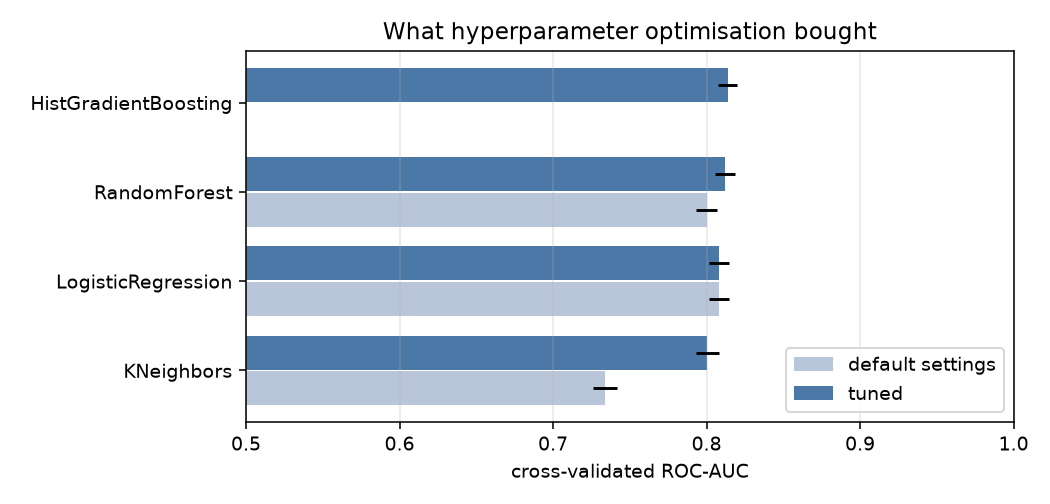

In [19]:
leaderboard = (pd.concat([tuned, gb_tuned], ignore_index=True)
                 .sort_values("roc_auc_mean", ascending=False))
display(leaderboard[["model", "roc_auc_mean", "roc_auc_std", "pr_auc_mean",
                     "f1_mean", "balanced_accuracy_mean", "brier_mean"]])

rb.plot_model_comparison(baseline, leaderboard, FIGURES / "05_model_comparison.png")
display(Image(str(FIGURES / "05_model_comparison.png")))

### 6.4 Held-out evaluation

Scored once, on data no fold and no search ever saw. Intervals are 2,000-sample percentile
bootstraps.

,metric,point_estimate,ci_lo_2.5,ci_hi_97.5,ci_width
0,roc_auc,0.8118,0.7982,0.8244,0.0262
1,pr_auc,0.6048,0.5770,0.6317,0.0547
2,f1,0.5022,0.4755,0.5278,0.0523
3,balanced_accuracy,0.6722,0.6588,0.6856,0.0268
4,brier,0.1272,0.1217,0.1329,0.0112


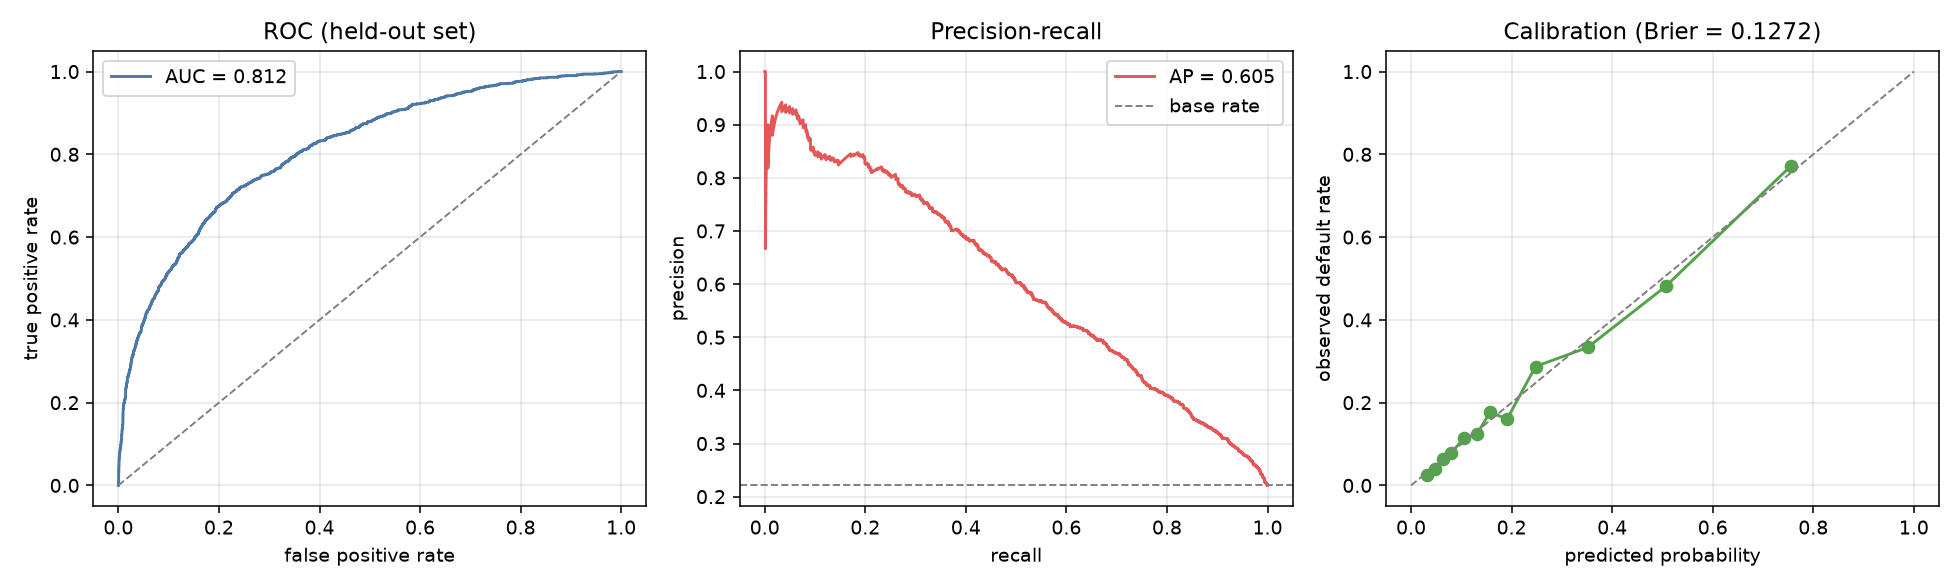

In [20]:
y_proba = best_model.predict_proba(X_test[full_cols])[:, 1]

boot = rb.bootstrap_test_metrics(y_test, y_proba, n_boot=2000)
display(boot)

rb.plot_evaluation(y_test, y_proba, FIGURES / "06_holdout_evaluation.png")
display(Image(str(FIGURES / "06_holdout_evaluation.png")))

### 6.5 Choosing a decision threshold

In [21]:
display(rb.threshold_table(y_test, y_proba))

,threshold,declined_pct,precision,recall,f1,defaults_caught,good_loans_rejected,defaults_missed,good_loans_approved
0,0.2,35.6,0.449,0.724,0.554,1043,1278,398,3796
1,0.3,24.3,0.535,0.588,0.560,847,735,594,4339
2,0.4,17.7,0.615,0.493,0.547,710,445,731,4629
3,0.5,12.6,0.692,0.394,0.502,568,253,873,4821
4,0.6,8.5,0.768,0.296,0.427,426,129,1015,4945
5,0.7,5.4,0.825,0.203,0.325,292,62,1149,5012


Ranking quality is threshold-free; an approve/decline policy is not. This table is where the
real trade-off gets made — how many good borrowers you are willing to turn away per default
avoided. No amount of hyperparameter search makes that choice for you.

---
## 7. Robustness and what tuning does not buy

### 7.1 Sample size and the learning curve

32k rows is a comfortable middle, but the **minority class is the binding constraint**: at a
~22% base rate, the effective sample for learning what default looks like is the ~7k
defaulters, not the 32k rows. Hence stratification everywhere, cross-validation rather than a
single split, and real caution about grades F and G, which hold only a few hundred rows
between them.

The learning curve answers whether more rows would help.

,train_size,train_mean,cv_mean,cv_std
0,2084,0.8904,0.7953,0.0095
1,4765,0.8616,0.8041,0.0079
2,7445,0.8450,0.8097,0.0063
3,10125,0.8393,0.8115,0.0068
4,12806,0.8383,0.8113,0.0070
5,15486,0.8365,0.8128,0.0063
6,18166,0.8337,0.8145,0.0058
7,20847,0.8326,0.8139,0.0061


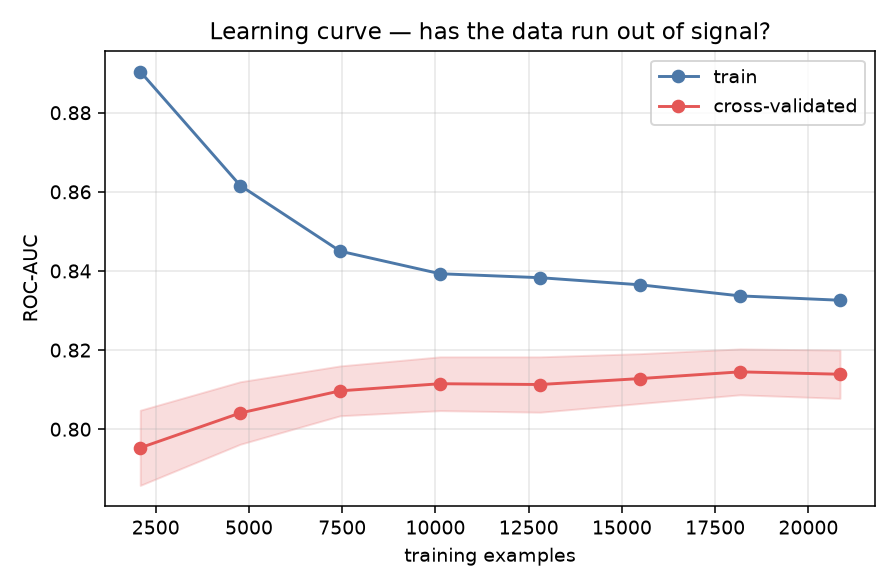

change in CV AUC over the final step: -0.0006


In [22]:
curve = rb.learning_curve_data(best_model, X_train, y_train, full_cols)
display(curve)

rb.plot_learning_curve(curve, FIGURES / "07_learning_curve.png")
display(Image(str(FIGURES / "07_learning_curve.png")))

slope = curve["cv_mean"].iloc[-1] - curve["cv_mean"].iloc[-2]
print(f"change in CV AUC over the final step: {slope:+.4f}")

Flat. The limit is the **information in these twelve columns**, not the number of rows.
Another 30k identical applications would buy almost nothing; new *columns* — payment history,
existing debt, a bureau DTI — would buy a great deal.

### 7.2 Does hyperparameter optimisation guarantee out-of-sample performance?

**No — and it is systematically optimistic.** Three separate reasons:

1. **The reported best score is a maximum over noisy estimates.** A search over *k* candidates
   returns the best of *k* noisy fold-averages, and part of that "best" is a lucky draw
   against those particular folds. §7.3 measures it.
2. **It optimises the metric you chose, on the distribution you happen to have.** Maximising
   ROC-AUC improves *ranking*. It does not improve calibration, and it knows nothing about the
   cost asymmetry between rejecting a good borrower and approving a bad one (§6.5).
3. **It assumes the future resembles the past.** Every guarantee cross-validation offers is
   conditional on new applicants coming from the same distribution. Credit portfolios break
   that routinely — rates move, the lender's own approval policy shifts, a recession arrives.

### 7.3 Nested cross-validation

An outer loop scoring the *whole procedure*, tuning included, on data the search never
touched. The gap against the inner score is the selection bias.

In [23]:
nested = rb.nested_cv(gb_spec, X_train, y_train, full_cols, n_iter=10)
print(f"tuned inner-CV score (what a naive report quotes) : {gb_search.best_score_:.4f}")
print(f"nested CV (honest estimate of the procedure)      : {nested['mean']:.4f} +/- {nested['std']:.4f}")
print(f"selection optimism                                : {gb_search.best_score_ - nested['mean']:+.4f}")
print(f"outer-fold scores                                 : {nested['outer_scores']}")

tuned inner-CV score (what a naive report quotes) : 0.8138
nested CV (honest estimate of the procedure)      : 0.8121 +/- 0.0068
selection optimism                                : +0.0017
outer-fold scores                                 : [0.8015, 0.8109, 0.809, 0.8198, 0.8191]


### 7.4 Bootstrap intervals

How precise the estimate is at all. Compare the interval width against the gaps between
models before claiming one is better than another.

In [24]:
auc_ci = boot.set_index("metric").loc["roc_auc"]
spread = leaderboard["roc_auc_mean"].max() - leaderboard["roc_auc_mean"].min()
print(f"held-out ROC-AUC               : {auc_ci['point_estimate']:.4f}  "
      f"95% CI [{auc_ci['ci_lo_2.5']:.4f}, {auc_ci['ci_hi_97.5']:.4f}]")
print(f"CI width                       : {auc_ci['ci_width']:.4f}")
print(f"spread across all tuned models : {spread:.4f}")
print(f"\n-> models separated by less than {auc_ci['ci_width']:.4f} AUC are not "
      f"distinguishable on this data.")

held-out ROC-AUC               : 0.8118  95% CI [0.7982, 0.8244]
CI width                       : 0.0262
spread across all tuned models : 0.0132

-> models separated by less than 0.0262 AUC are not distinguishable on this data.


### 7.5 Seed and partition sensitivity

Re-run cross-validation under different fold partitions. If the score swings with the
partition, the ranking of models is noise.

In [25]:
seeds = rb.seed_sensitivity(best_model, X_train, y_train, full_cols)
display(seeds)
print(f"spread across seeds: {seeds.attrs['spread']:.4f}")

,seed,mean,std
0,0,0.8124,0.0084
1,1,0.8131,0.0057
2,7,0.8136,0.0096
3,13,0.8125,0.0059
4,42,0.8138,0.0061


spread across seeds: 0.0014


### 7.6 Slice-level evaluation

An average hides the segments. A model can look strong overall while being close to useless
inside the segment where the decision is actually hard.

In [26]:
subgroups = rb.subgroup_performance(X_test.reset_index(drop=True), y_test.to_numpy(), y_proba)
display(subgroups)

within = subgroups["roc_auc"].dropna()
print(f"per-slice AUC ranges {within.min():.3f} to {within.max():.3f} "
      f"(overall {auc_ci['point_estimate']:.3f})")

,slice,value,n,roc_auc,default_rate
0,loan_grade,A,2094,0.7305,0.098
1,loan_grade,B,2079,0.7212,0.160
2,loan_grade,C,1371,0.7343,0.230
3,loan_grade,D,719,0.7277,0.576
4,loan_grade,E,200,0.7580,0.660
5,loan_grade,F,35,NaN,0.714
6,loan_grade,G,17,NaN,1.000
7,person_home_ownership,MORTGAGE,2464,0.8046,0.134
8,person_home_ownership,OTHER,23,NaN,0.174
9,person_home_ownership,OWN,379,0.8323,0.106


per-slice AUC ranges 0.721 to 0.832 (overall 0.812)


Within a single `loan_grade` the model has far less to work with than the headline number
suggests — because the grade itself carries most of the signal. That is the practical meaning
of the post-treatment problem raised in §3.5.

### 7.7 What this dataset cannot support

Two checks belong in production but need data this file does not carry:

- **Out-of-time validation** — train on older vintages, test on newer. The only honest test of
  drift, and impossible here: there are no origination dates.
- **Reject inference** — the file contains only approved loans, so a model deployed to make
  approval decisions would immediately face a population it never saw. Either score rejected
  applications too, or state plainly that the model describes approved-loan risk only.

And one practice worth naming: monitor **calibration** drift, not just AUC. A ranking can stay
good while the absolute probabilities drift, and the book still gets mispriced.

---
## 8. Summary

In [27]:
summary = pd.DataFrame([
    ("rows after cleaning", f"{len(frame):,}"),
    ("default base rate", f"{frame[TARGET].mean():.2%}"),
    ("dependent variable", TARGET),
    ("best model", leaderboard.iloc[0]["model"]),
    ("tuned CV ROC-AUC", f"{gb_search.best_score_:.4f}"),
    ("nested CV ROC-AUC", f"{nested['mean']:.4f} +/- {nested['std']:.4f}"),
    ("selection optimism", f"{gb_search.best_score_ - nested['mean']:+.4f}"),
    ("held-out ROC-AUC", f"{auc_ci['point_estimate']:.4f} "
                         f"[{auc_ci['ci_lo_2.5']:.4f}, {auc_ci['ci_hi_97.5']:.4f}]"),
    ("bootstrap CI width", f"{auc_ci['ci_width']:.4f}"),
    ("seed spread", f"{seeds.attrs['spread']:.4f}"),
    ("learning-curve final step", f"{slope:+.4f}"),
    ("data source", dataset.source),
], columns=["quantity", "value"])
display(summary)

,quantity,value
0,rows after cleaning,"32,574"
1,default base rate,22.12%
2,dependent variable,loan_status
3,best model,HistGradientBoosting
4,tuned CV ROC-AUC,0.8138
5,nested CV ROC-AUC,0.8121 +/- 0.0068
6,selection optimism,+0.0017
7,held-out ROC-AUC,"0.8118 [0.7982, 0.8244]"
8,bootstrap CI width,0.0262
9,seed spread,0.0014


### Takeaways

1. **`loan_status` is the dependent variable**; everything else is an input or the lender's
   own pricing decision.
2. **`loan_percent_income` is the strongest applicant-side signal** — the ratio matters, not
   income or loan size alone. `loan_grade` and `loan_int_rate` are stronger still, but they
   are the underwriter's verdict rather than independent measurements.
3. **Gradient boosting wins, but not by a defensible margin.** The bootstrap interval on the
   held-out set is wider than the gaps between the tuned models, so they are statistically
   indistinguishable on this data.
4. **Tuning bought a number, not a better model.** Nested CV shows part of the tuned score is
   selection luck, and the learning curve is flat — the ceiling is the feature set, not the
   sample size or the hyperparameters.